<a href="https://colab.research.google.com/github/HamzaEric/seedlings_classification_CV/blob/main/Notebooks/Data%20Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install torchinfo

In [5]:
import os
from pathlib import Path
import torch
import kagglehub
from torchvision import datasets, transforms
import shutil
from matplotlib import pyplot as plt
import numpy as np
import collections
from sklearn.model_selection import train_test_split
import random
from torch.utils.data import Subset, DataLoader
from collections import defaultdict
import torch.nn as nn
import torch.nn.functional as F
import time
import copy
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import pandas as pd
from torchvision import models
from torchinfo import summary
import pickle


In [6]:
# You may need to re-run this cell after logging in.
kagglehub.login()
path = kagglehub.competition_download('plant-seedlings-classification')

100%|██████████| 1.69G/1.69G [01:31<00:00, 19.9MB/s]

Extracting files...


# **Augmentation Strategies (Theory)**

**Why Data Augmentation?**

Data augmentation artificially **expands the training dataset** by applying random transformations to existing images. This simulates new variations **without requiring extra manual labeling** and helps models generalize better to unseen data.

- In the **Plant Seedlings** dataset:
  - Seedlings appear at different **orientations** (tilted stems, rotated leaves).
  - Lighting and **soil backgrounds** vary across images.
  - Some species are **visually similar** (e.g., *Black-grass* vs *Loose Silky-bent*), making overfitting likely.

By applying augmentation during training, we **expose the model to these variations** on-the-fly.

**Common Augmentation Techniques**

1. **Spatial Transforms**
   - Random horizontal/vertical flips
   - Random rotations
   - Random resized crops (zoom-in effects)

2. **Color Jitter**
   - Random brightness, contrast, saturation, hue adjustments

3. **Noise & Blur (optional)**
   - Gaussian noise or blur to simulate camera/environment variability

**Impact on Training**

- **Benefits:**
  - Reduces overfitting by increasing data diversity
  - Encourages learning of **invariant features** (e.g., shape over color)

- **Trade-offs:**
  - Slightly longer training (augments images each epoch)
  - Augmentation strength must be balanced (too strong can harm accuracy)

**Conceptual Flow**

```text
Raw Image → Random Augmentation (flip/rotate/jitter) → Tensor Conversion & Normalize → Model Input
```

In [7]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"
original_test_dir = os.path.join(data_path, "test")
new_parent_dir = os.path.join(data_path, "test_dir")

os.makedirs(new_parent_dir, exist_ok=True)

if os.path.exists(original_test_dir):
    shutil.move(original_test_dir, new_parent_dir)

In [8]:
data_path = "/root/.cache/kagglehub/competitions/plant-seedlings-classification"

test_data_path = os.path.join(data_path, "test_dir")
train_dir = os.path.join(data_path, "train")

# -----------------------------
#  Transformations
# -----------------------------
IMG_SIZE = 224
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),  # rotate ±20 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]    # ImageNet std
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
#  Load datasets
# -----------------------------
train_dataset = datasets.ImageFolder(train_dir, transform=transform)

test_dataset  = datasets.ImageFolder(test_data_path, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# -----------------------------
#  Verify
# -----------------------------
print(f"Train Classes: {train_dataset.classes}")
print(f"Test Classes found: {test_dataset.classes}")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Test Classes found: ['test']
Train samples: 4750 | Test samples: 794


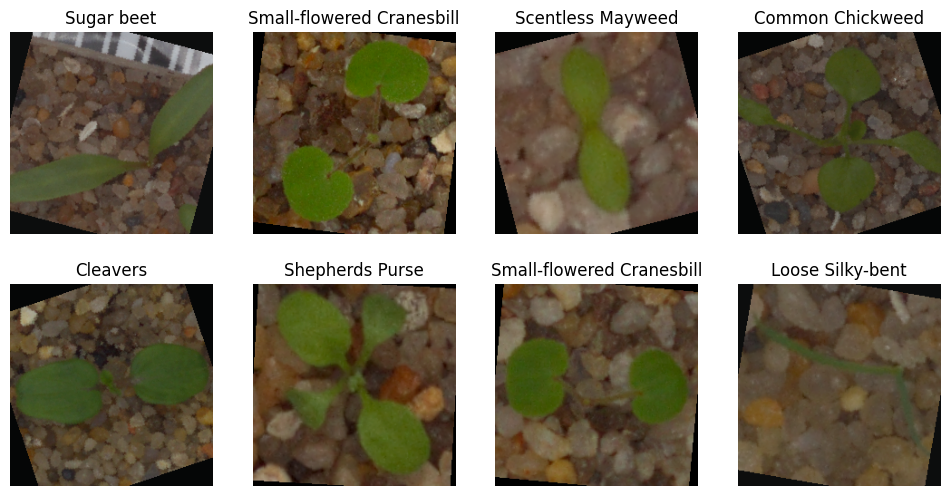

In [9]:
def imshow(inp, title=None):
    """Display a tensor image after unnormalizing (ImageNet stats)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Show first 8 training images
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i], title=train_dataset.classes[labels[i]])
plt.show()

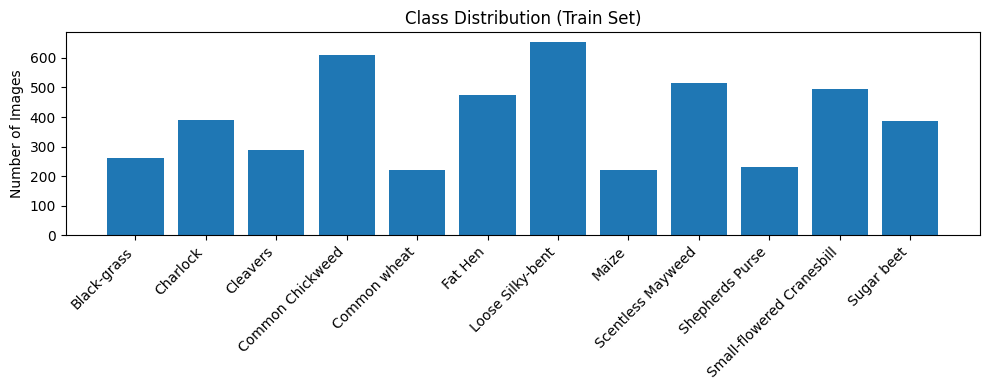

In [10]:
class_counts = collections.Counter([label for _, label in train_dataset.samples])

# Convert to list aligned with class_names
counts = [class_counts[i] for i in range(len(train_dataset.classes))]

# Plot
plt.figure(figsize=(10, 4))
plt.bar(train_dataset.classes, counts)
plt.xticks(rotation=45, ha='right')
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [11]:
CT_train_loader_bs20 = DataLoader(train_dataset, batch_size=32, shuffle=True)
CT_test_loader_bs50  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

CT_tr20_images, CT_tr20_labels = next(iter(CT_train_loader_bs20))
CT_te50_images, CT_te50_labels = next(iter(CT_test_loader_bs50))

CT_train_bs20_shape = CT_tr20_images.shape
CT_test_bs50_shape  = CT_te50_images.shape

print("CT_train_bs20_shape:", CT_train_bs20_shape)
print("CT_test_bs50_shape:",  CT_test_bs50_shape)

CT_train_bs20_shape: torch.Size([32, 3, 224, 224])
CT_test_bs50_shape: torch.Size([32, 3, 224, 224])


In [12]:
val_dir   = os.path.join(data_path, "val")

os.makedirs(val_dir, exist_ok=True)

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    # All images in this class
    images = [
        os.path.join(class_path, f)
        for f in os.listdir(class_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    # Skip if validation already exists for this class
    val_class_path = os.path.join(val_dir, class_name)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path, exist_ok=True)

    # 15% split for validation
    train_imgs, val_imgs = train_test_split(images, test_size=0.15, random_state=42)

    # Move validation images
    for img in val_imgs:
        dest_path = os.path.join(val_class_path, os.path.basename(img))
        shutil.move(img, dest_path)

print(f"Validation split created at: {val_dir}")

Validation split created at: /root/.cache/kagglehub/competitions/plant-seedlings-classification/val


In [16]:
test_dir = os.path.join(data_path, "test")

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(test_data_path, transform=val_test_transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {train_dataset.classes}")


Train samples: 4030
Val samples: 720
Test samples: 794
Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']


In [17]:
# -----------------------------
# Create 33% stratified subset
# -----------------------------
# Group indices by class
class_indices = defaultdict(list)
for idx, (_, label) in enumerate(train_dataset):
    class_indices[label].append(idx)

# Sample 33% from each class
subset_indices = []
for class_label, indices in class_indices.items():
    n_samples = len(indices) // 3  # 33% of each class
    sampled_indices = random.sample(indices, n_samples)
    subset_indices.extend(sampled_indices)

# Create subset
train_dataset = Subset(train_dataset, subset_indices)

# -----------------------------
# 4. DataLoaders
# -----------------------------
BATCH_SIZE = 8
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# -----------------------------
# 5. Verify
# -----------------------------
print(f"Classes: {train_dataset.dataset.classes}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Train: 1341 | Val: 720 | Test: 794


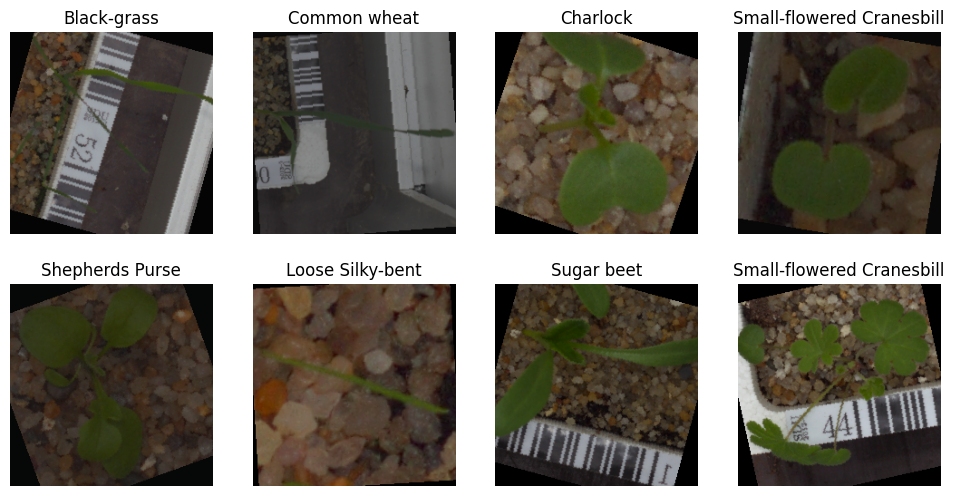

In [18]:
def imshow(inp, title=None):
    """Display a tensor image after unnormalizing (ImageNet stats)."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title:
        plt.title(title)
    plt.axis('off')

# Show first 8 images from train set
images, labels = next(iter(train_loader))
fig = plt.figure(figsize=(12, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i], title=train_dataset.dataset.classes[labels[i]])
plt.show()


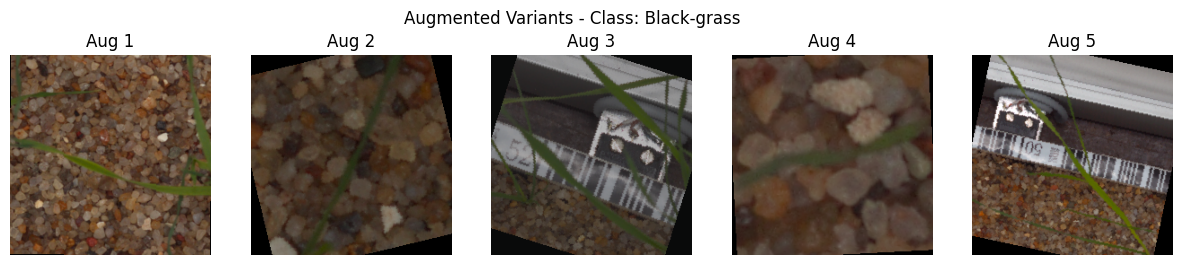

In [21]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD = np.array([0.229, 0.224, 0.225])

def unnormalize(img_tensor):
    """Undo ImageNet normalization for visualization."""
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = IMAGENET_STD * img + IMAGENET_MEAN
    img = np.clip(img, 0, 1)
    return img

# Pick one image, show multiple augmented versions
sample_img, sample_label = train_dataset[0]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img_aug, _ = train_dataset[i]  # new augmentations each access
    axes[i].imshow(unnormalize(img_aug))
    axes[i].axis('off')
    axes[i].set_title(f"Aug {i+1}")
plt.suptitle(f"Augmented Variants - Class: {train_dataset.dataset.classes[sample_label]}")
plt.show()

In [22]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 212MB/s]


In [23]:
resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
summary(resnet18, input_size=(1, 3, 224, 224), col_names=["input_size", "output_size", "num_params"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
ResNet                                   [1, 3, 224, 224]          [1, 1000]                 --
├─Conv2d: 1-1                            [1, 3, 224, 224]          [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 112, 112]         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3     

In [25]:
for param in resnet18.parameters():
    param.requires_grad = False

In [26]:
num_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_features, 12)  # 12 plant species
model_aug = resnet18

In [27]:
print(resnet18)

trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable parameters (classifier head only): {trainable_params:,}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [31]:
def train_model_aug(model_aug, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=4, device='cpu'):
        """
        Training loop for transfer learning:
        - Only classifier head updates (backbone frozen).
        - Tracks train/validation loss and accuracy.
        """
        since = time.time()

        best_model_wts = copy.deepcopy(model_aug.state_dict())
        best_loss = float('inf')

        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

        model_aug = model_aug.to(device)

        for epoch in range(num_epochs):
            print(f'Epoch {epoch+1}/{num_epochs}')
            print('-' * 20)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model_aug.train()
                    loader = train_loader
                else:
                    model_aug.eval()
                    loader = val_loader

                running_loss = 0.0
                running_corrects = 0
                total_samples = 0

                for batch_idx, (inputs, labels) in enumerate(tqdm(loader, desc=f'{phase.capitalize()}', leave=False)):
                    inputs, labels = inputs.to(device), labels.to(device)

                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model_aug(inputs)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # Stats
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += (outputs.argmax(1) == labels).sum().item()
                    total_samples += labels.size(0)

                epoch_loss = running_loss / total_samples
                epoch_acc = running_corrects / total_samples

                history[f'{phase}_loss'].append(epoch_loss)
                history[f'{phase}_acc'].append(epoch_acc)

                # Track best model (lowest val loss)
                if phase == 'val' and epoch_loss < best_loss:
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model_aug.state_dict())

                print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if scheduler is not None:
                scheduler.step()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s')
        print(f'Best val loss: {best_loss:.4f}')

        # Load best weights
        model_aug.load_state_dict(best_model_wts)

        return model_aug, history

In [32]:
model_aug, history_transfer = train_model_aug(
        model_aug, criterion, optimizer, scheduler,
        train_loader, val_loader,
        num_epochs=10, device=device
    )

Epoch 1/10
--------------------


Train Loss: 2.2878 Acc: 0.2245


Val Loss: 1.9156 Acc: 0.3222
Epoch 2/10
--------------------


Train Loss: 1.8538 Acc: 0.3863


Val Loss: 1.6692 Acc: 0.4486
Epoch 3/10
--------------------


...

Val Loss: 1.1091 Acc: 0.6306
Epoch 9/10
--------------------


Train Loss: 1.1655 Acc: 0.6540


Val Loss: 1.0585 Acc: 0.6542
Epoch 10/10
--------------------


Train Loss: 1.1890 Acc: 0.6324


Val Loss: 1.1110 Acc: 0.6361
Training complete in 6m 25s
Best val loss: 1.0585


In [33]:
torch.save(model_aug.state_dict(), "resnet18 + augmentation.pth")

    # Save the training history
with open('resnet + aug.pkl', 'wb') as f:
    pickle.dump(history_transfer, f)

print("Model and training history saved!")

Model and training history saved!


In [34]:
model_aug.load_state_dict(torch.load("resnet18 + augmentation.pth", map_location='cpu'))
model_aug.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Training history loaded successfully!


ResNet18 + Aug Validation Accuracy: 65.42%


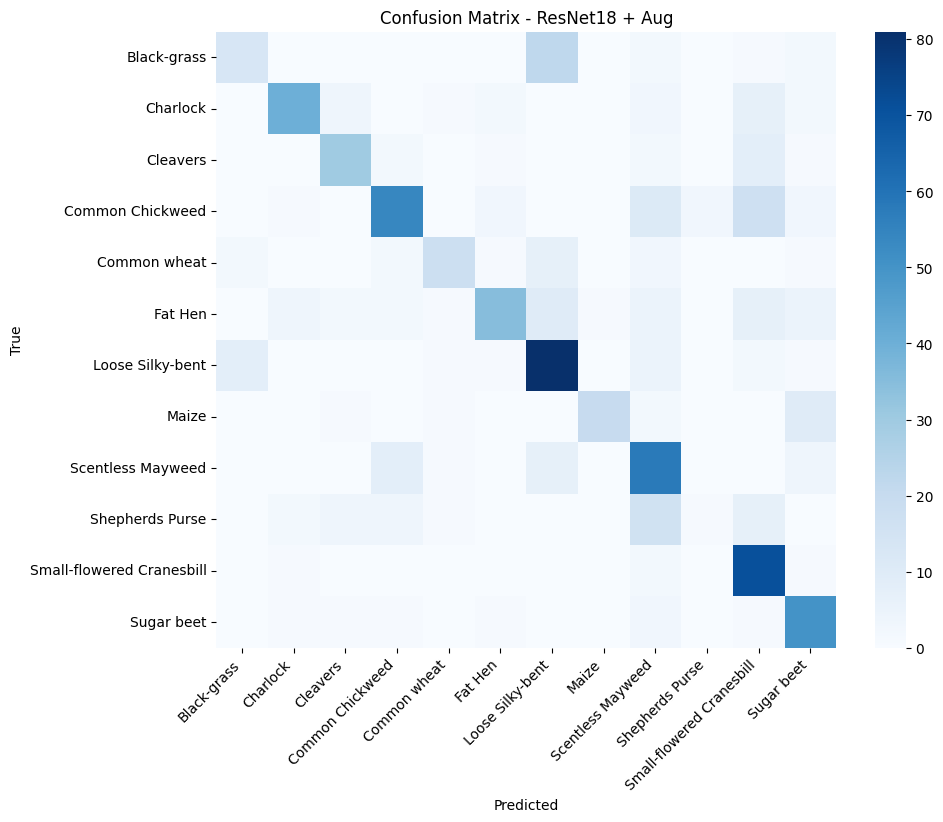


Classification Report:
                           precision    recall  f1-score   support

              Black-grass       0.57      0.33      0.41        40
                 Charlock       0.82      0.68      0.74        59
                 Cleavers       0.71      0.68      0.70        44
         Common Chickweed       0.74      0.59      0.65        92
             Common wheat       0.75      0.53      0.62        34
                  Fat Hen       0.80      0.49      0.60        72
         Loose Silky-bent       0.64      0.82      0.72        99
                    Maize       0.95      0.59      0.73        34
        Scentless Mayweed       0.52      0.74      0.61        78
          Shepherds Purse       0.25      0.03      0.05        35
Small-flowered Cranesbill       0.59      0.95      0.72        75
               Sugar beet       0.62      0.86      0.72        58

                 accuracy                           0.65       720
                macro avg       0.66

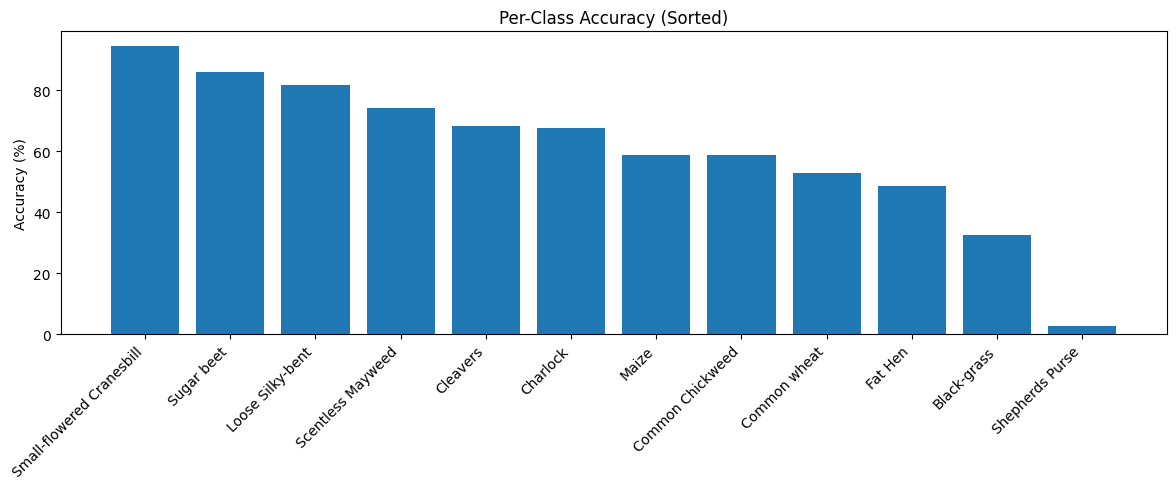

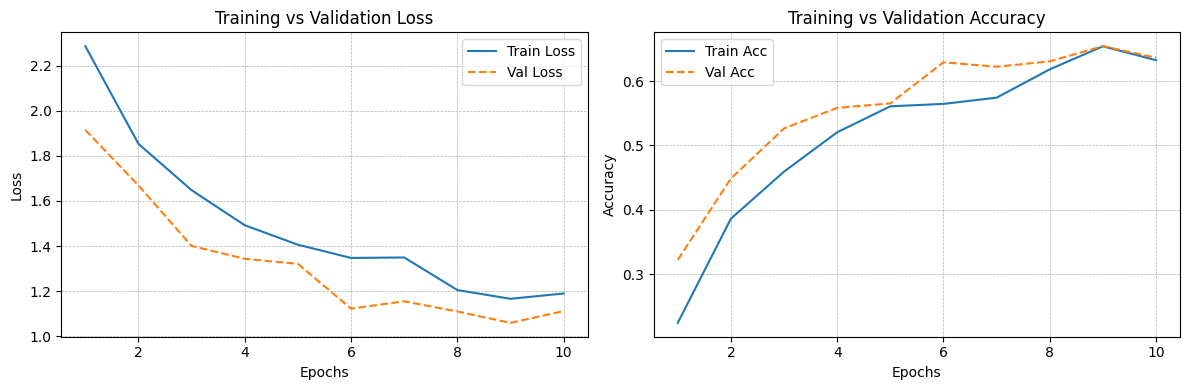

In [35]:
# -----------------------------
# 0. Setup & Load History
# -----------------------------
with open('resnet + aug.pkl', 'rb') as f:
    history_transfer = pickle.load(f)
print("Training history loaded successfully!")

# Detect device dynamically to match your model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_aug = model_aug.to(device)

# Get correct class names from the training set
class_names = train_dataset.dataset.classes if hasattr(train_dataset, 'dataset') else train_dataset.classes

# -----------------------------
# 1. Helper: Evaluate model
# -----------------------------
def evaluate_model(model, loader, device='cpu'):
    model_aug.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_aug(inputs)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return acc, np.array(all_labels), np.array(all_preds)

# -----------------------------
# 2. Evaluate on VALIDATION set
# -----------------------------
val_acc, y_true, y_pred = evaluate_model(model_aug, val_loader, device=device)
print(f"ResNet18 + Aug Validation Accuracy: {val_acc:.2%}")

# -----------------------------
# 3. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.title("Confusion Matrix - ResNet18 + Aug")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.show()

# -----------------------------
# 4. Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -----------------------------
# 5. Per-Class Accuracy
# -----------------------------
class_correct = np.diag(cm)
class_totals = cm.sum(axis=1)
class_accuracy = class_correct / class_totals * 100

# Sort by accuracy
sorted_idx = np.argsort(-class_accuracy)
sorted_classes = [class_names[i] for i in sorted_idx]
sorted_acc = class_accuracy[sorted_idx]

plt.figure(figsize=(12, 5))
plt.bar(sorted_classes, sorted_acc)
plt.xticks(rotation=45, ha='right')
plt.title("Per-Class Accuracy (Sorted)")
plt.ylabel("Accuracy (%)")
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Compare Training Curves
# -----------------------------
epochs = range(1, len(history_transfer['train_loss']) + 1)

plt.figure(figsize=(12, 4))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history_transfer['train_loss'], label="Train Loss")
plt.plot(epochs, history_transfer['val_loss'], label="Val Loss", linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history_transfer['train_acc'], label="Train Acc")
plt.plot(epochs, history_transfer['val_acc'], label="Val Acc", linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [36]:
model_aug.eval()
test_preds = []


with torch.no_grad():
    for inputs, _ in tqdm(test_loader, desc="Generating Predictions"):
        inputs = inputs.to(device)
        outputs = model_aug(inputs)
        preds = outputs.argmax(1)
        test_preds.extend(preds.cpu().numpy())

filenames = [os.path.basename(path) for path, _ in test_dataset.samples]


predicted_species = [class_names[p] for p in test_preds]


df = pd.DataFrame({
    'file': filenames,
    'species': predicted_species
})

df.to_csv('resnet_18 + aug.csv', index=False)
print("\nSuccessfully saved predictions to resnet_18 + aug.csv!")


print(df.head())

Generating Predictions: 100%|██████████| 100/100 [00:05<00:00, 16.75it/s]


Successfully saved predictions to resnet_18 + aug.csv!
            file                    species
0  0021e90e4.png  Small-flowered Cranesbill
1  003d61042.png  Small-flowered Cranesbill
2  007b3da8b.png                 Sugar beet
3  0086a6340.png                    Fat Hen
4  00c47e980.png                 Sugar beet


/tmp/ipykernel_653/4256088703.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


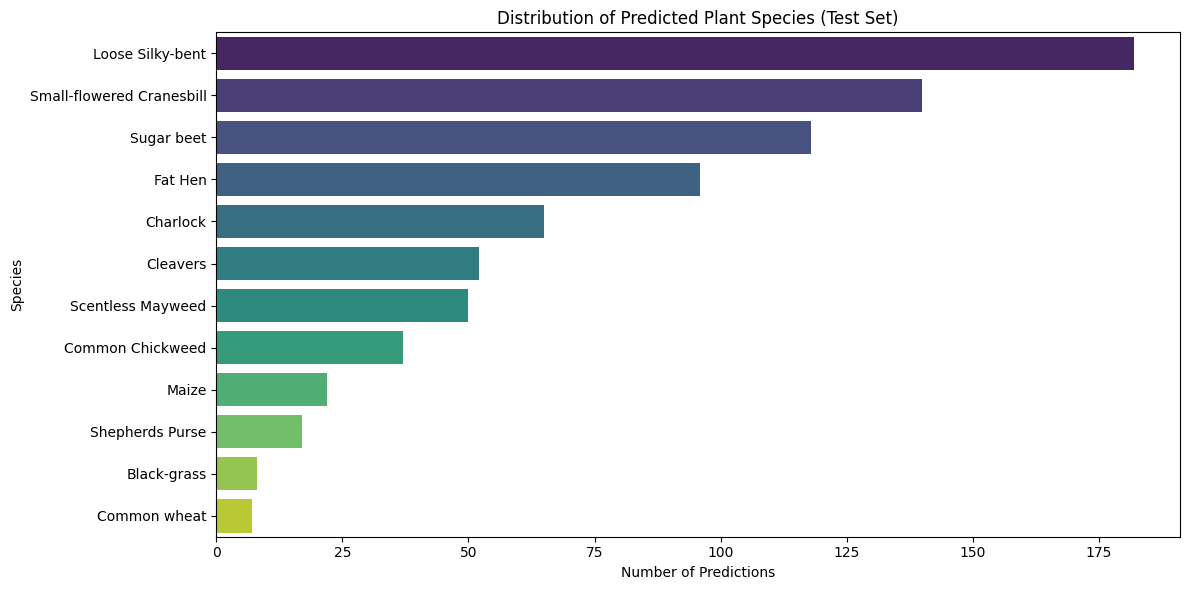

In [37]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y='species',
    order=df['species'].value_counts().index,
    palette='viridis'
)

plt.title("Distribution of Predicted Plant Species (Test Set)")
plt.xlabel("Number of Predictions")
plt.ylabel("Species")
plt.tight_layout()